# Fine-Tune Pretrained Commutative CNN Classifier

Load the pretrained commutative CNN encoder and fine-tune the full network on the current labeled action dataset.

In [1]:
%load_ext autoreload
%autoreload 2

from dataclasses import asdict
from pathlib import Path

import pandas as pd

from src.ml import (
    CommutativeCNNClassifier,
    LossWeightConfig,
    OptimizationConfig,
    display_experiment_summary,
    display_holdout_evaluation,
    fit_chunked_water_vs_other_hot_start,
    fit_estimator_on_experiment,
    load_commutative_cnn_pretraining_config,
    persist_experiment_artifacts,
    plot_training_history,
    prepare_multitask_experiment_data,
    prepare_water_vs_other_pretraining_data,
)
from src.dataset_config import load_current_dataset_artifact_path
from src.tensor_utils import (
    build_tensor_embedding_2d,
    load_labeled_tensor_dataset,
    plot_tensor_embedding_2d,
)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.set_option("display.expand_frame_repr", False)


In [2]:
# User inputs

dataset_artifact_path = load_current_dataset_artifact_path()
unlabeled_dataset_path = Path(".dataset_cache/unlabeled_active_high_mid_low_t20_z5_y96_x96_chunks")
pretraining_config_path = Path("artifacts/pretrained_commutative_cnn/config.yaml")
pretraining_config = load_commutative_cnn_pretraining_config(pretraining_config_path)
print(f"Loaded commutative CNN pretraining config from {pretraining_config_path}")
print(pretraining_config)

pretrained_encoder_path = pretraining_config.pretrained_encoder_path
if not pretrained_encoder_path.exists():
    raise FileNotFoundError(
        f"Pretrained CNN encoder not found at {pretrained_encoder_path}. "
        "Run 10C_pretrain_commutative_cnn_encoder.ipynb first, or update "
        "artifacts/pretrained_commutative_cnn/config.yaml to point at an existing checkpoint."
    )
model_config = pretraining_config.model_config
experiment_output_dir = Path("artifacts/nb13C_commutative_cnn_full_finetune")
binary_loss_plot_dir = experiment_output_dir / "loss_plots" / "binary_hot_start"
fine_tune_loss_plot_dir = experiment_output_dir / "loss_plots" / "fine_tune"
persist_artifacts = True
print(f"Using pretrained encoder checkpoint: {pretrained_encoder_path.resolve()}")
print(f"Binary hot-start loss PDFs: {binary_loss_plot_dir.resolve()}")
print(f"Fine-tune loss PDFs: {fine_tune_loss_plot_dir.resolve()}")

holdout_fraction = 0.25
validation_fraction_within_train = 0.20
train_num_random_rotations = 1
rotation_range_degrees = 5.0
run_binary_hot_start = True
binary_pretraining_epochs = 45
binary_learning_rate = 2.5e-5
binary_weight_decay = 5e-4
binary_class_weighting = "balanced"

optimization_config = OptimizationConfig(
    batch_size=8,
    epochs=120,
    learning_rate=2e-5,
    weight_decay=5e-4,
    early_stopping_patience=16,
    early_stopping_min_delta=1e-4,
    early_stopping_start_epoch=15,
    early_stopping_monitor="loss",
    early_stopping_smoothing="median",
    early_stopping_smoothing_window=5,
    scheduler_patience=5,
    scheduler_factor=0.5,
    scheduler_min_lr=1e-6,
    training_plot_dir=str(fine_tune_loss_plot_dir),
    training_plot_every_n_epochs=1,
    validation_split=0.0,
    random_state=0,
    standardize=True,
    device=None,
    verbose=True,
    class_weighting=None,
)
loss_weight_config = LossWeightConfig(
    action_weight=1.0,
    water_vs_other_weight=1.0,
    compound_weight=0.0,
    concentration_weight=0.0,
    latent_alignment_weight=0.0,
    lambda_align=0.0,
)


Loaded commutative CNN pretraining config from artifacts/pretrained_commutative_cnn/config.yaml
CommutativeCNNPretrainingConfig(unlabeled_dataset_path=PosixPath('.dataset_cache/unlabeled_active_high_mid_low_t20_z5_y96_x96_chunks'), pretrained_encoder_path=PosixPath('artifacts/pretrained_commutative_cnn/encoder_state_v6.pt'), validation_fraction=0.15, train_num_random_rotations=0, rotation_range_degrees=0.0, model_config=CommutativeCNNConfig(spatial_conv_channels=(16, 32), spatial_kernel_size_z=(3, 1), spatial_kernel_size_xy=(5, 3), spatial_stride_z=(1, 1), spatial_stride_xy=(1, 1), spatial_pool_kernel_z=(1, 1), spatial_pool_kernel_xy=(2, 2), spatial_pool_stride_z=(1, 1), spatial_pool_stride_xy=(2, 2), temporal_st_channels=(48, 64), temporal_st_kernel_sizes=(5, 3), temporal_ts_channels=(32, 48, 64), temporal_ts_kernel_sizes=(7, 5, 3), spatial_agg_channels=(32, 64), spatial_agg_kernel_size_z=(3, 1), spatial_agg_kernel_size_xy=(3, 3), spatial_agg_stride_z=(1, 1), spatial_agg_stride_xy=(1,

## Output Review

The previous binary hot-start run reached its best validation region around epoch `020` (`val_loss=0.6472`) with `learning_rate=5e-5`, then became noisier and drifted upward. The next run lowers the binary hot-start learning rate to `2.5e-5` and allows `45` epochs; the training loop now reports/restores the selected best epoch, so the extra budget is only for giving the lower learning rate room to converge.

The full fine-tune was still improving at epoch `090` (`val_loss=1.3884`, action loss `0.7476`), so the next run extends the budget to `120` epochs and patience to `16` while keeping `learning_rate=2e-5`, `weight_decay=5e-4`, and `water_vs_other_weight=1.0`. Exact latent alignment remains explicitly disabled with `latent_alignment_weight=0.0` / `lambda_align=0.0`; the encoder alignment now comes from the pretrained prototype objective in 10C.

In [3]:
dataset = load_labeled_tensor_dataset(dataset_artifact_path)
experiment = prepare_multitask_experiment_data(
    dataset,
    holdout_fraction=holdout_fraction,
    validation_fraction_within_train=validation_fraction_within_train,
    train_num_random_rotations=train_num_random_rotations,
    rotation_range_degrees=rotation_range_degrees,
    random_state=optimization_config.random_state,
)
display_experiment_summary(experiment)

,split,n_samples
0,train_augmented,336
1,train_base,168
2,val,42
3,holdout,71


,mechanism_of_action,compound,concentration_band,n_samples
0,GABAAR_Antagonist,Gabazine,high,14
1,GABAAR_Antagonist,Bemegride,control,14
2,AChE_Inhibitor_Reversible,Galantamine,high,12
3,GABAAR_Antagonist,Gabazine,control,12
4,mAChR_Agonist_NonSelective,Bethanechol,high,12
5,mAChR_Agonist_NonSelective,Bethanechol,mid,12
6,mAChR_Agonist_NonSelective,Muscarine,high,12
7,NMDAR_Activation,Cis-ACPD,control,12
8,mAChR_Agonist_NonSelective,Pilocarpine,high,10
9,mAChR_Agonist_NonSelective,Bethanechol,control,10


## Memory Note

The unlabeled pretraining chunks are large and `load_unlabeled_tensor_dataset(...)` concatenates them into one CPU tensor. This notebook keeps the intended water-vs-other hot-start, but runs it with `fit_chunked_water_vs_other_hot_start(...)`, which scans and trains from chunks instead of materializing the full unlabeled tensor in RAM. Supervised rotation augmentation is reduced because it materializes augmented labeled tensors in memory before fitting.

Writing binary hot-start loss PDFs to: /run/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/ZebraFish/artifacts/nb13C_commutative_cnn_full_finetune/loss_plots/binary_hot_start
Binary hot-start optimizer: lr=5e-05, weight_decay=0.0005, class_weighting=balanced
Commutative CNN model: parameters=170,252 trainable=170,252 size=0.65 MB
001/035 lr=5.00e-05 eta=12:27:54 train_loss=0.7093 val_loss=0.6915 train_acc=0.752 val_acc=0.754
002/035 lr=5.00e-05 eta=11:00:30 train_loss=0.6913 val_loss=0.6703 train_acc=0.717 val_acc=0.692
003/035 lr=5.00e-05 eta=9:51:44 train_loss=0.6811 val_loss=0.6627 train_acc=0.712 val_acc=0.631
004/035 lr=5.00e-05 eta=9:08:36 train_loss=0.6736 val_loss=0.7334 train_acc=0.647 val_acc=0.253
005/035 lr=5.00e-05 eta=8:35:26 train_loss=0.6735 val_loss=0.6688 train_acc=0.689 val_acc=0.458
006/035 lr=5.00e-05 eta=8:08:56 train_loss=0.6704 val_loss=0.6830 train_acc=0.692 val_acc=0.402
007/035 lr=5.00e-05 eta=7:54:30 train_loss=0.6715 val_loss=0.6510 

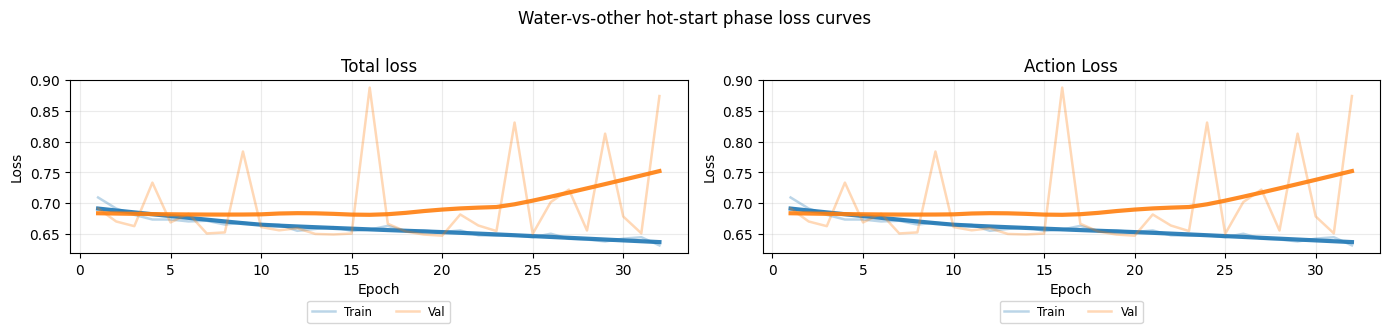

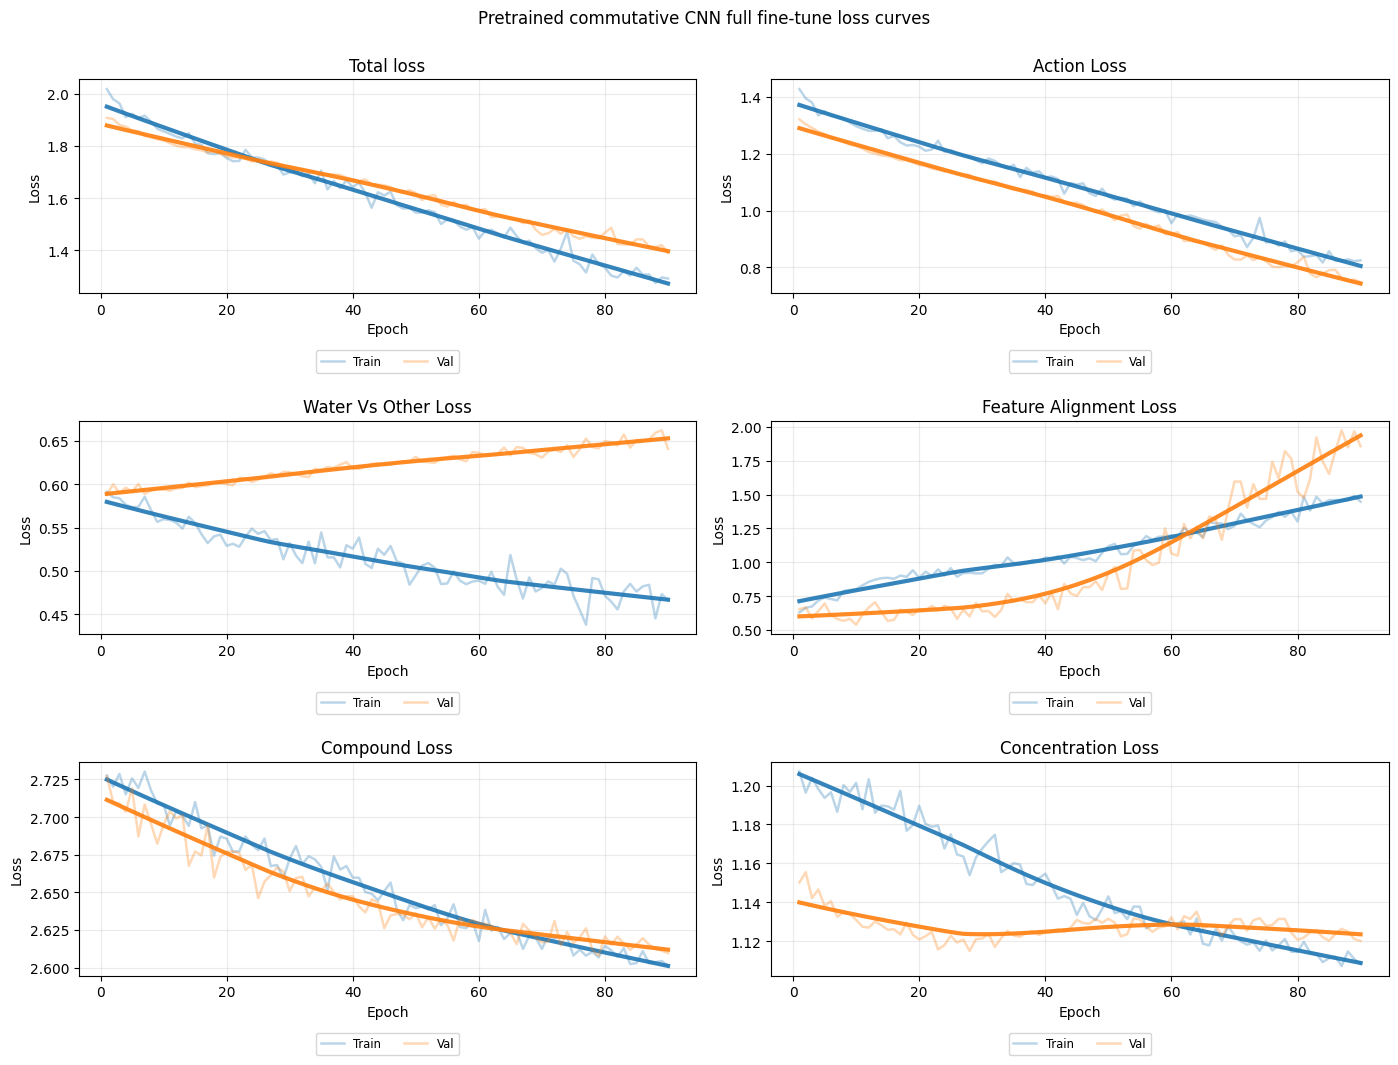

In [4]:
model = CommutativeCNNClassifier(
    model_config=model_config,
    optimization_config=optimization_config,
    loss_weight_config=loss_weight_config,
    pretrained_state_path=pretrained_encoder_path,
    freeze_backbone=False,
    hot_start=True,
)

binary_pretraining_data = None
binary_pretraining_history = None
if run_binary_hot_start and binary_pretraining_epochs > 0:
    final_epochs = model.epochs
    final_learning_rate = model.learning_rate
    final_weight_decay = model.weight_decay
    model.training_plot_dir = str(binary_loss_plot_dir)
    model.training_plot_title = "Water-vs-other hot-start loss curves"
    model.learning_rate = binary_learning_rate
    model.weight_decay = binary_weight_decay
    print(f"Writing binary hot-start loss PDFs to: {binary_loss_plot_dir.resolve()}")
    print(f"Binary hot-start optimizer: lr={model.learning_rate:g}, weight_decay={model.weight_decay:g}, class_weighting={binary_class_weighting}")
    binary_pretraining_data = fit_chunked_water_vs_other_hot_start(
        model,
        unlabeled_dataset_path,
        holdout_metadata=experiment.splits.metadata_holdout,
        validation_fraction=validation_fraction_within_train,
        epochs=binary_pretraining_epochs,
        random_state=optimization_config.random_state,
        class_weighting=binary_class_weighting,
    )
    binary_pretraining_history = model.history_.copy()
    plot_training_history(model, title="Water-vs-other hot-start phase loss curves", loess_frac=0.6);
    model.epochs = final_epochs
    model.learning_rate = final_learning_rate
    model.weight_decay = final_weight_decay

model.training_plot_dir = str(fine_tune_loss_plot_dir)
model.training_plot_title = "Pretrained commutative CNN full fine-tune loss curves"
print(f"Writing fine-tune loss PDFs to: {fine_tune_loss_plot_dir.resolve()}")
fit_estimator_on_experiment(model, experiment)
plot_training_history(model, title="Pretrained commutative CNN full fine-tune loss curves", loess_frac=0.6);



## Holdout report: action (including control)


,precision,recall,f1-score,support
class,,,,
Water,0.410256,0.640000,0.500000,25.0
GABAAR_Antagonist,0.833333,0.416667,0.555556,12.0
NMDAR_Activation,0.800000,0.800000,0.800000,10.0
AChE_Inhibitor_Reversible,0.312500,0.416667,0.357143,12.0
mAChR_Agonist_NonSelective,0.000000,0.000000,0.000000,12.0


,value
accuracy,0.478873
macro_precision,0.471218
macro_recall,0.454667
macro_f1,0.442540
weighted_precision,0.450795
weighted_recall,0.478873
weighted_f1,0.442991
n_samples,71.000000
roc_auc_ovr_macro,0.730973
average_precision_macro,0.506078


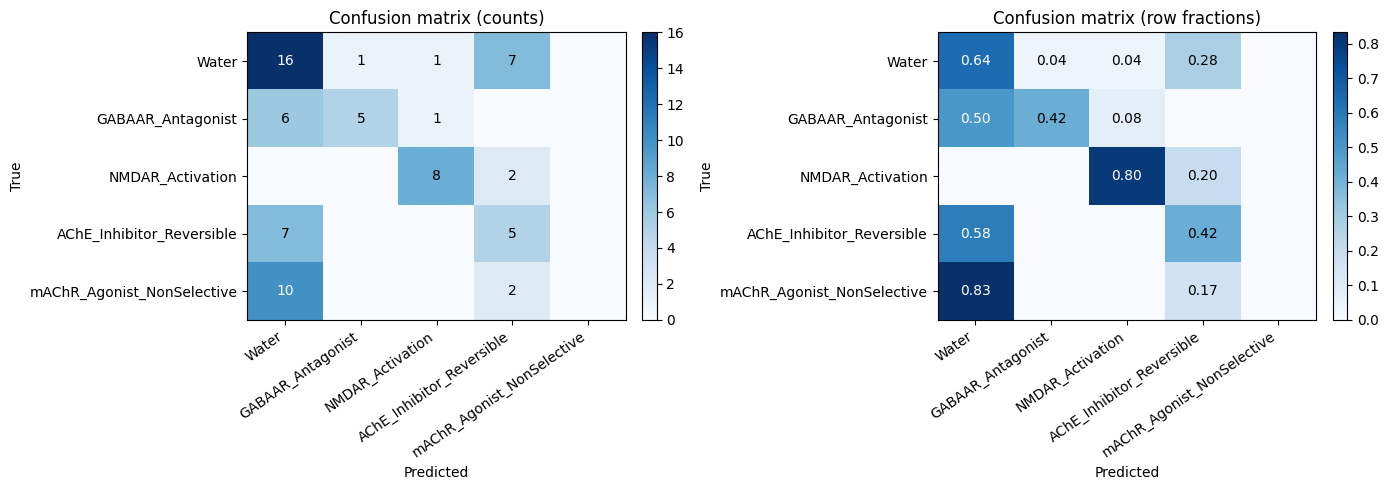


## Holdout report: compound (including control)


,precision,recall,f1-score,support
class,,,,
Control,0.000000,0.000000,0.000000,25.0
Bemegride,0.000000,0.000000,0.000000,6.0
Bicuculline,0.000000,0.000000,0.000000,3.0
Gabazine,0.000000,0.000000,0.000000,3.0
(RS)-(Tetrazol-5-yl)glycine,0.000000,0.000000,0.000000,3.0
Cis-ACPD,0.090909,0.333333,0.142857,3.0
N-methyl-D-aspartate,0.000000,0.000000,0.000000,4.0
Donepezil,0.000000,0.000000,0.000000,4.0
Galantamine,0.000000,0.000000,0.000000,4.0


,value
accuracy,0.042254
macro_precision,0.012474
macro_recall,0.112179
macro_f1,0.020110
weighted_precision,0.009131
weighted_recall,0.042254
weighted_f1,0.014067
n_samples,71.000000
roc_auc_ovr_macro,0.558765
average_precision_macro,0.173991


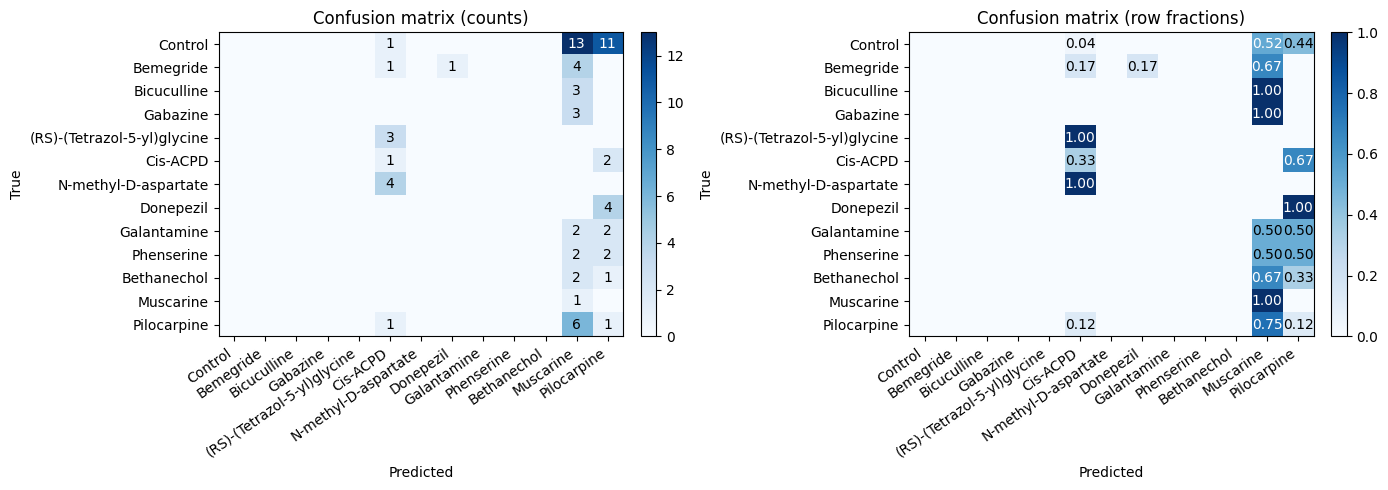


## Holdout report: concentration (including control)


,precision,recall,f1-score,support
class,,,,
control,0.370370,0.40,0.384615,25.0
high,0.261905,0.44,0.328358,25.0
mid,0.000000,0.00,0.000000,21.0


,value
accuracy,0.295775
macro_precision,0.210758
macro_recall,0.280000
macro_f1,0.237658
weighted_precision,0.222632
weighted_recall,0.295775
weighted_f1,0.251047
n_samples,71.000000
roc_auc_ovr_macro,0.429607
average_precision_macro,0.312442


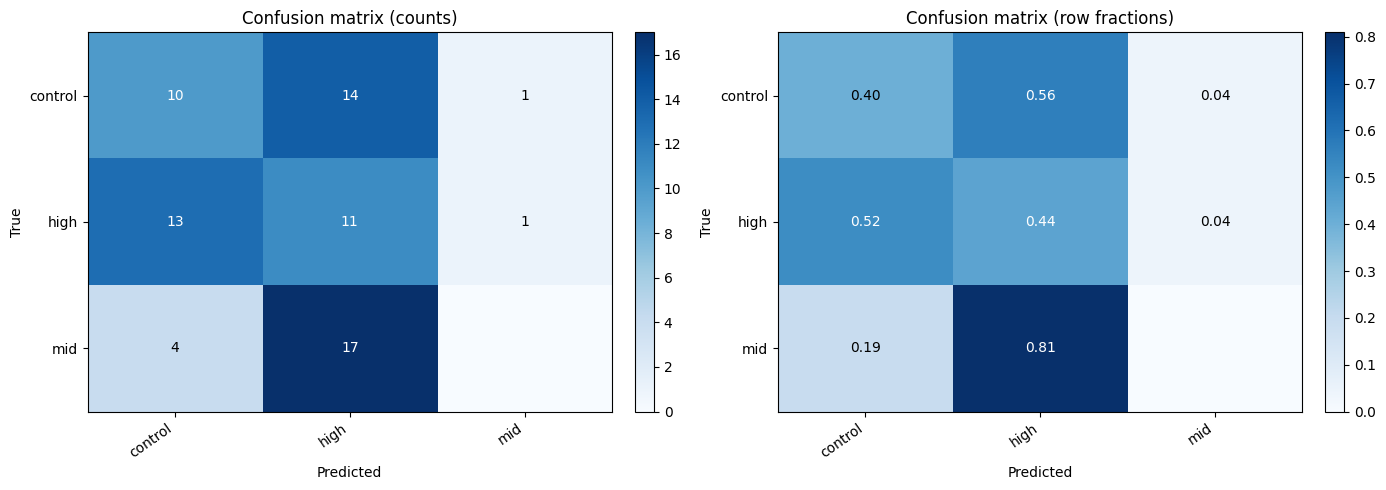


## Holdout report: action (excluding control; probabilities renormalized)


,precision,recall,f1-score,support
class,,,,
GABAAR_Antagonist,1.000000,0.750000,0.857143,12.0
NMDAR_Activation,0.888889,0.800000,0.842105,10.0
AChE_Inhibitor_Reversible,0.692308,0.750000,0.720000,12.0
mAChR_Agonist_NonSelective,0.666667,0.833333,0.740741,12.0


,value
accuracy,0.782609
macro_precision,0.811966
macro_recall,0.783333
macro_f1,0.789997
weighted_precision,0.808621
weighted_recall,0.782609
weighted_f1,0.787732
n_samples,46.000000
roc_auc_ovr_macro,0.896160
average_precision_macro,0.747105


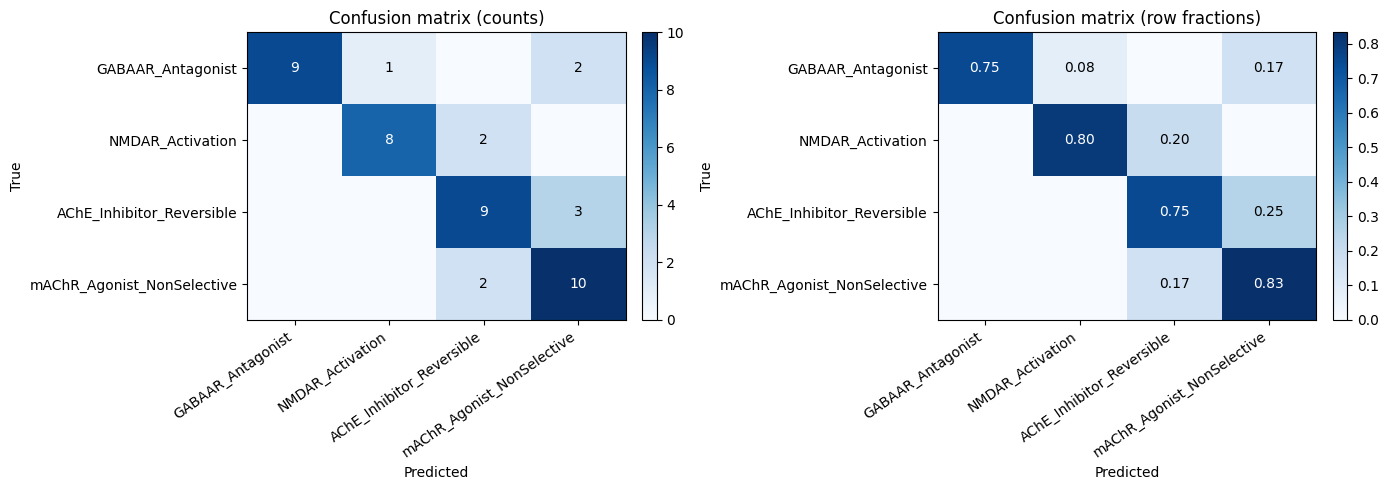


## Holdout report: compound (excluding control; probabilities renormalized)


,precision,recall,f1-score,support
class,,,,
Bemegride,0.000000,0.000000,0.000000,6.0
Bicuculline,0.000000,0.000000,0.000000,3.0
Gabazine,0.000000,0.000000,0.000000,3.0
(RS)-(Tetrazol-5-yl)glycine,0.000000,0.000000,0.000000,3.0
Cis-ACPD,0.100000,0.333333,0.153846,3.0
N-methyl-D-aspartate,0.000000,0.000000,0.000000,4.0
Donepezil,0.000000,0.000000,0.000000,4.0
Galantamine,0.000000,0.000000,0.000000,4.0
Phenserine,0.000000,0.000000,0.000000,4.0


,value
accuracy,0.065217
macro_precision,0.018901
macro_recall,0.121528
macro_f1,0.028098
weighted_precision,0.021960
weighted_recall,0.065217
weighted_f1,0.029236
n_samples,46.000000
roc_auc_ovr_macro,0.554733
average_precision_macro,0.196563


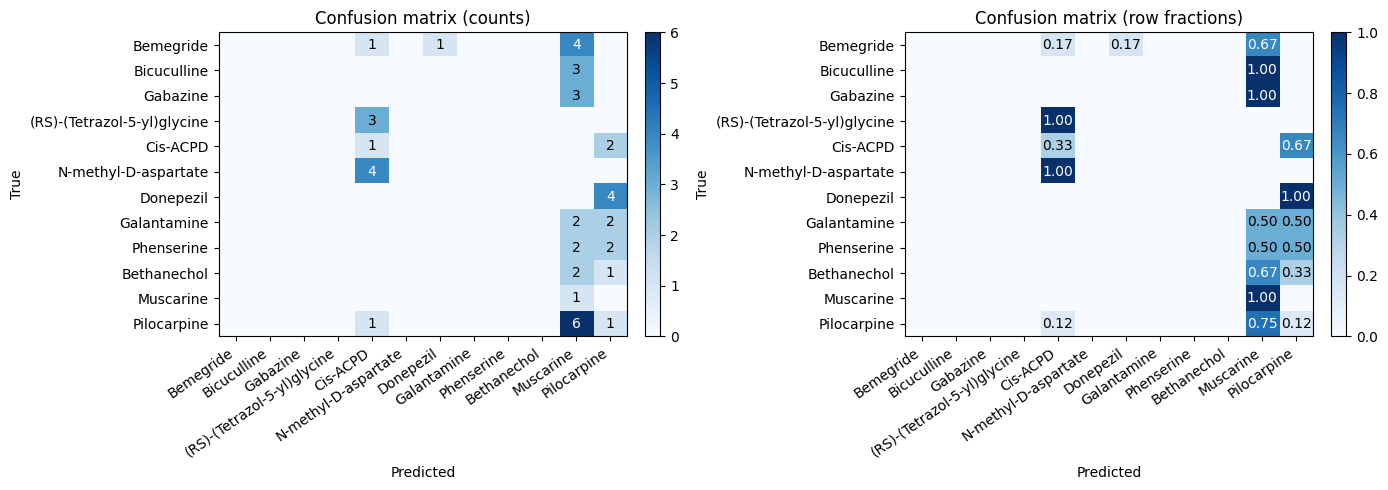


## Holdout report: concentration (excluding control; probabilities renormalized)


,precision,recall,f1-score,support
class,,,,
high,0.500000,0.800000,0.615385,25.0
mid,0.166667,0.047619,0.074074,21.0


,value
accuracy,0.456522
macro_precision,0.333333
macro_recall,0.423810
macro_f1,0.344729
weighted_precision,0.347826
weighted_recall,0.456522
weighted_f1,0.368265
n_samples,46.000000
roc_auc,0.316190
average_precision,0.357939


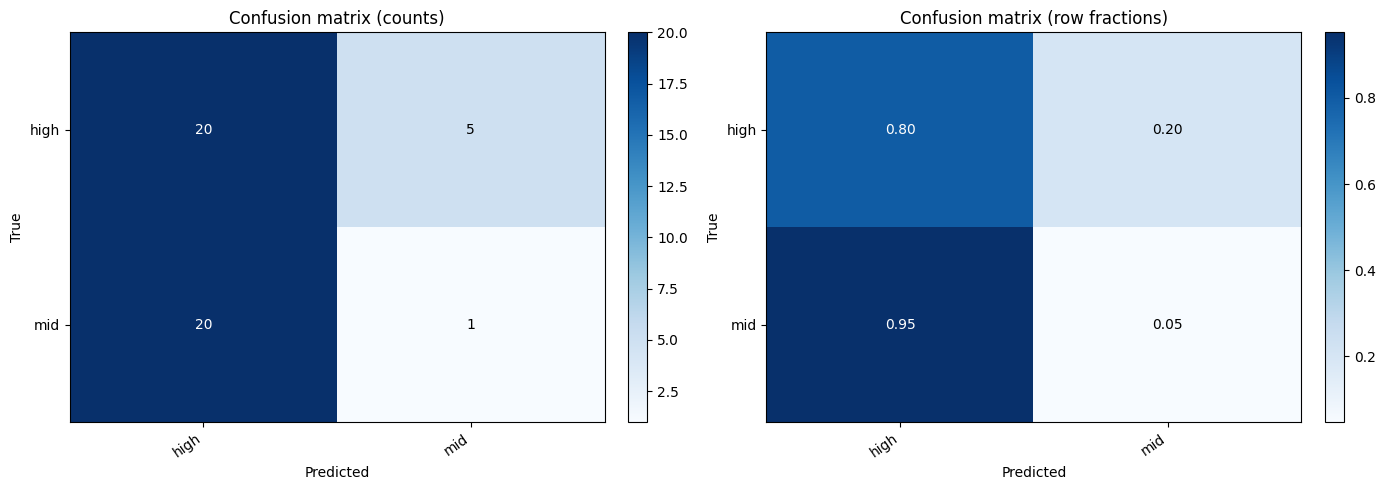

In [5]:
holdout_evaluation = display_holdout_evaluation(model, experiment)

(<Figure size 1550x1050 with 1 Axes>,
 <Axes: title={'center': 'Holdout embedding projection by action'}, xlabel='Component 1', ylabel='Component 2'>)

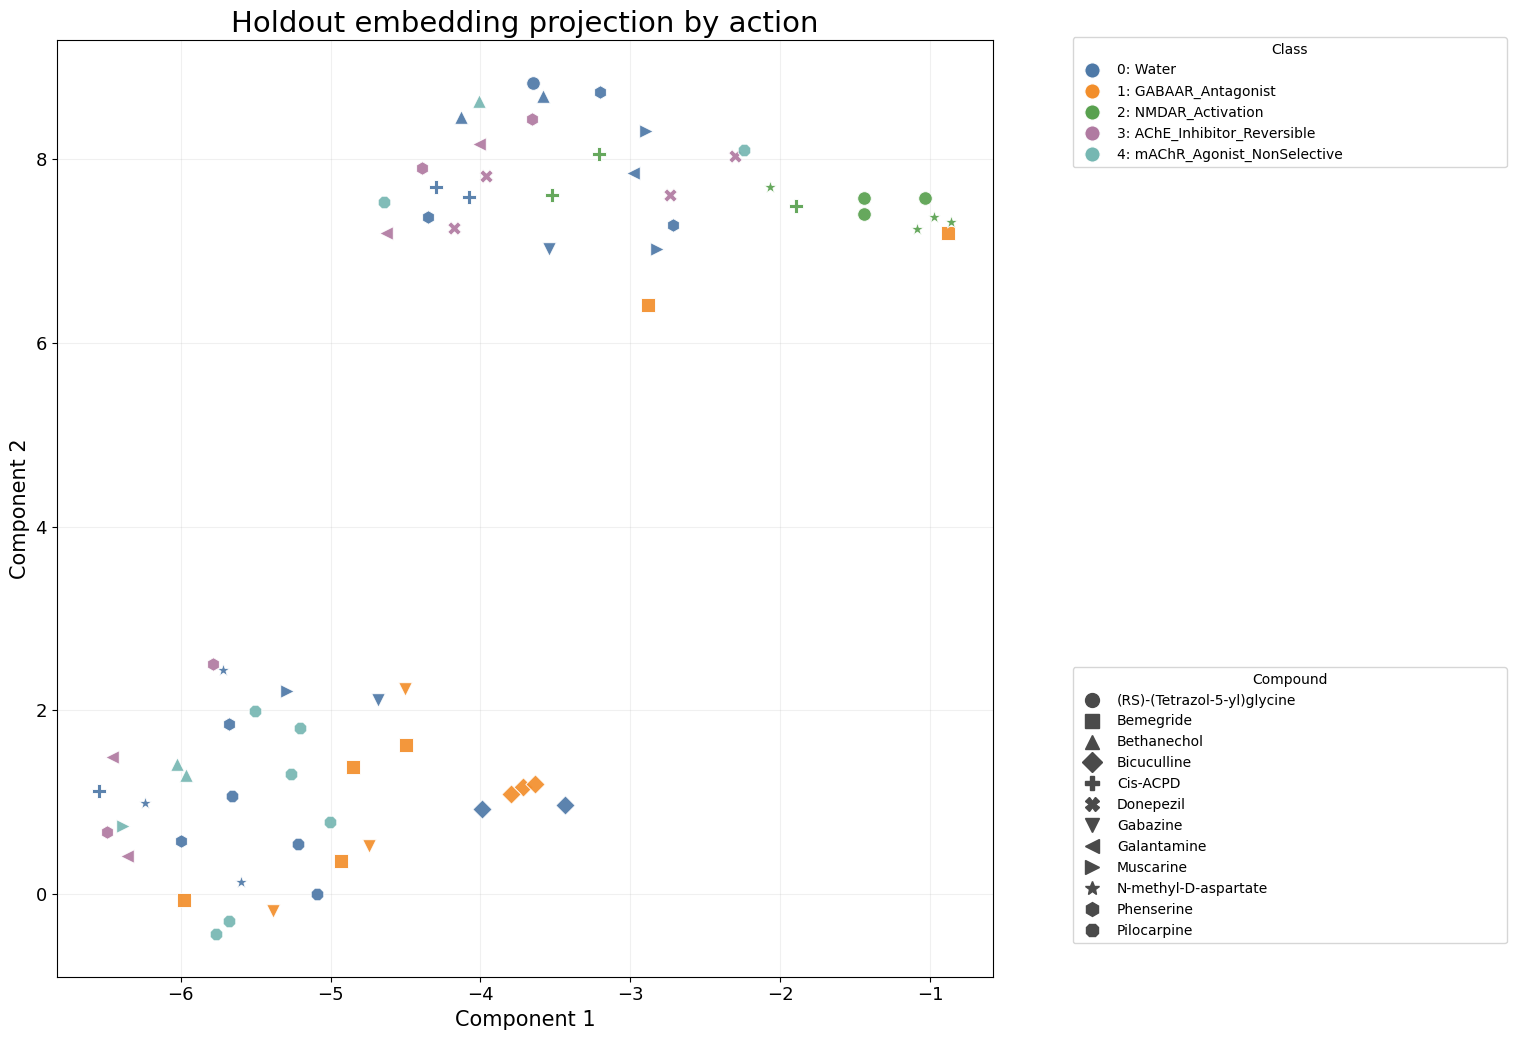

In [6]:
holdout_embedding_projection = build_tensor_embedding_2d(
    model.transform(experiment.splits.X_holdout),
    experiment.y_true_holdout["action"],
    label_map=experiment.label_maps["action"],
    metadata=experiment.splits.metadata_holdout,
    method="umap",
    random_state=optimization_config.random_state,
)
plot_tensor_embedding_2d(
    holdout_embedding_projection,
    title="Holdout embedding projection by action",
    marker_column="compound",
)

(<Figure size 1550x1050 with 1 Axes>,
 <Axes: title={'center': 'All labeled data embedding projection by action (controls hidden)'}, xlabel='Component 1', ylabel='Component 2'>)

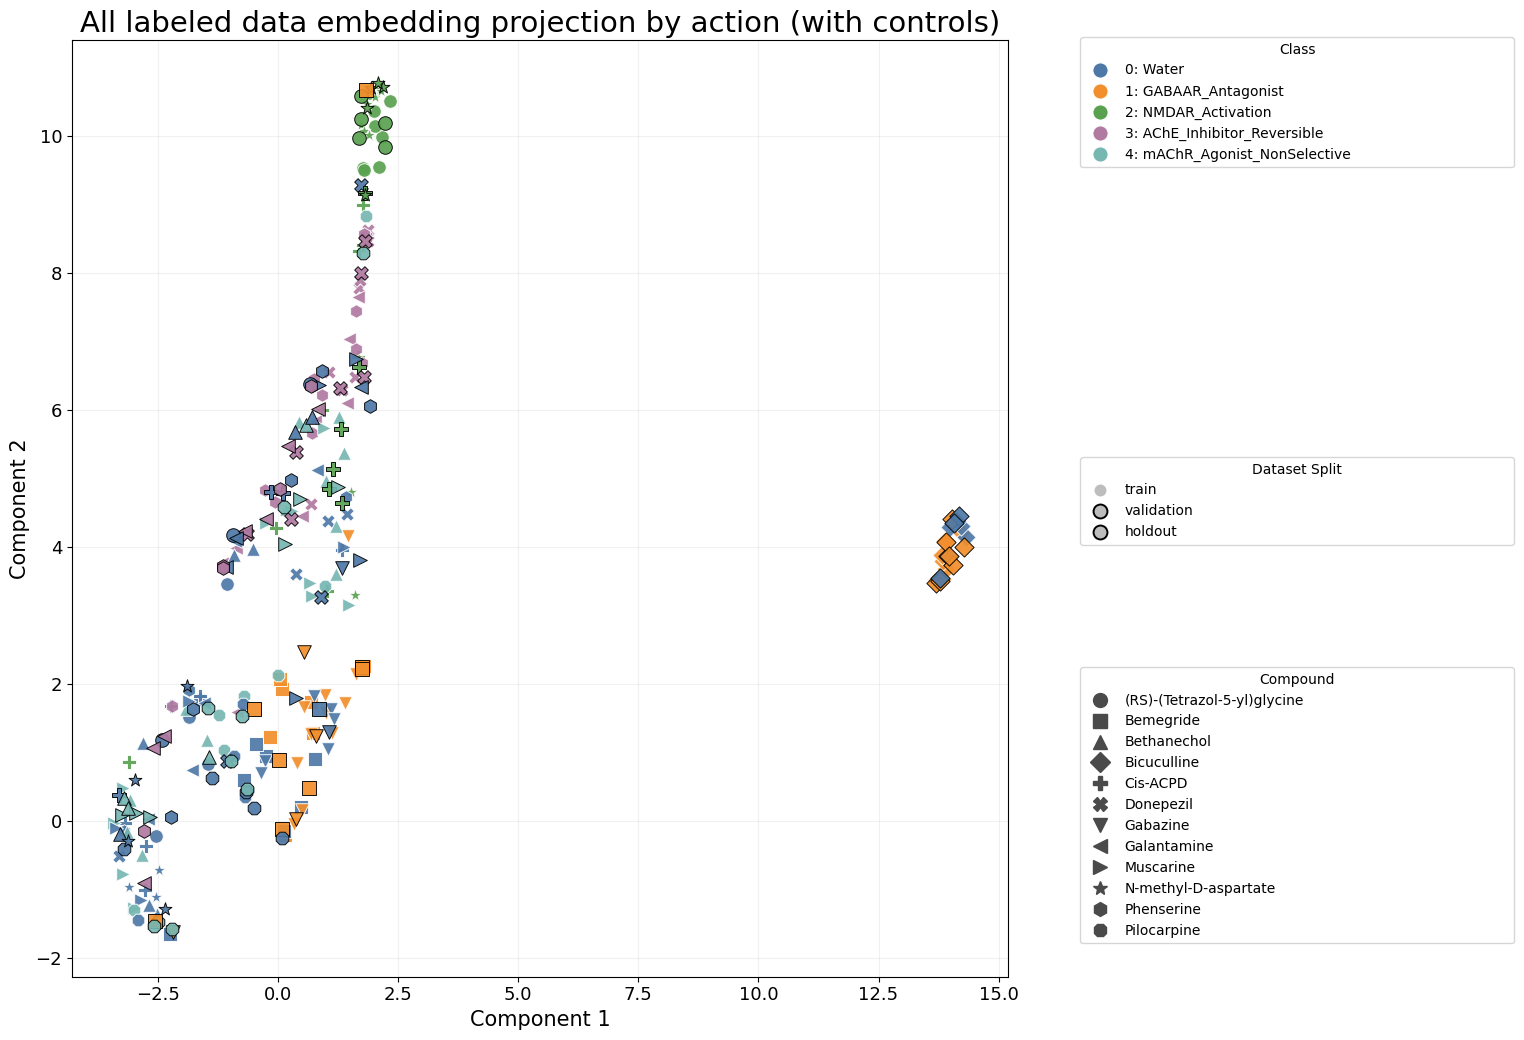

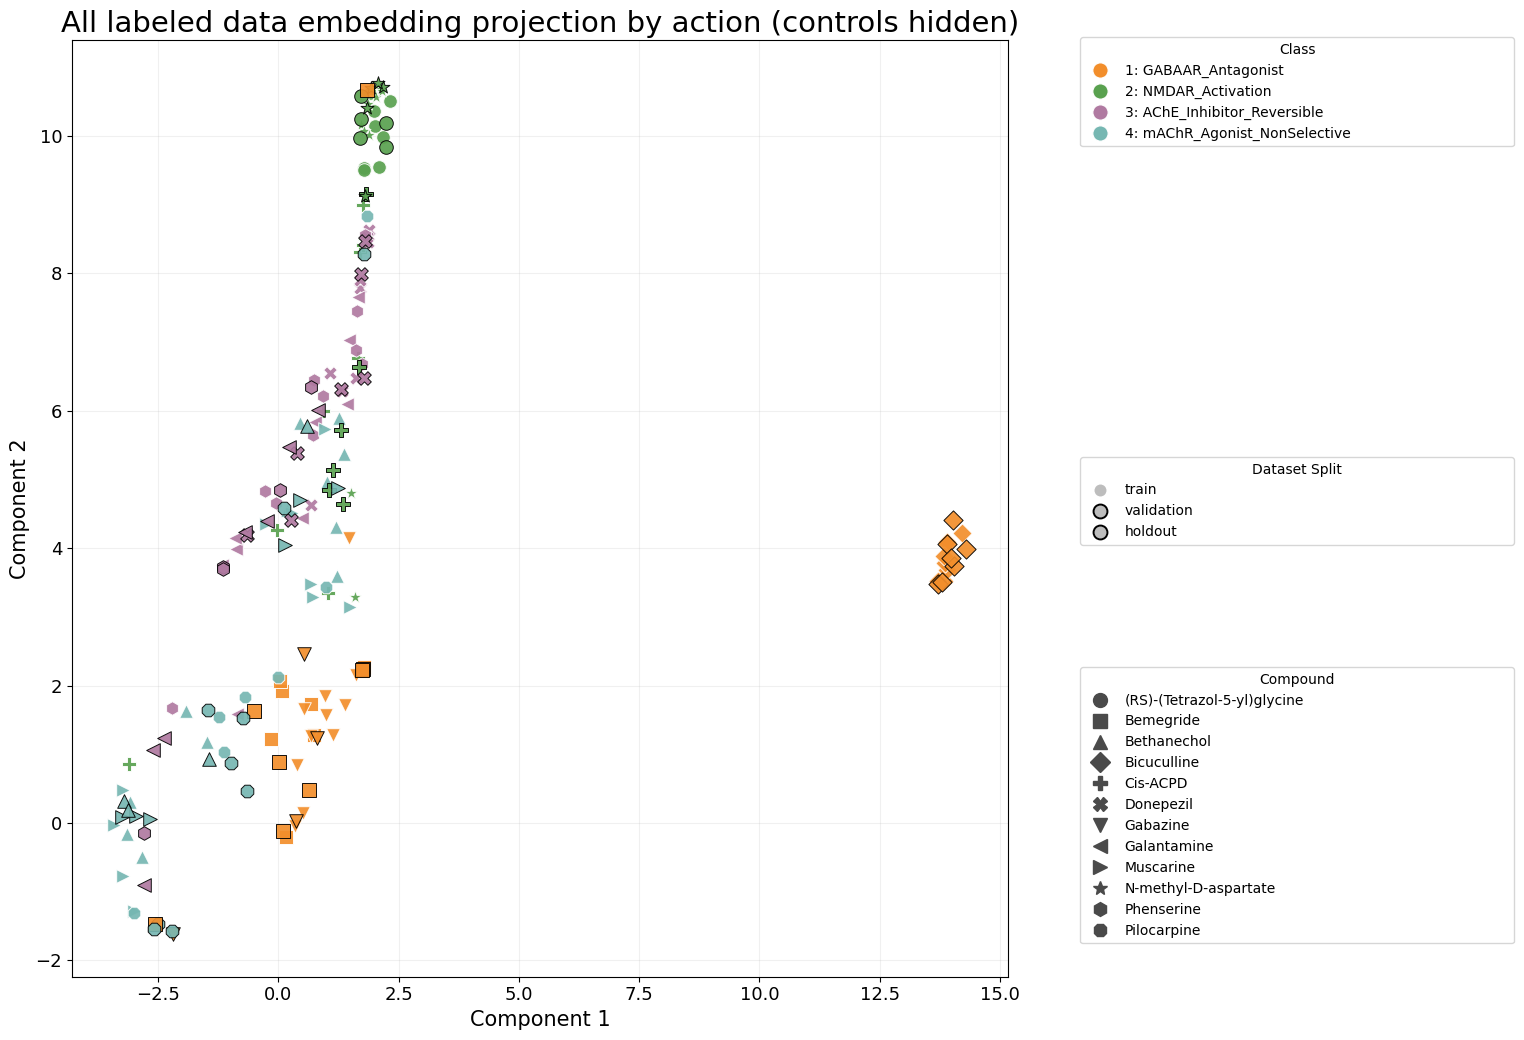

In [7]:
import torch

all_labeled_tensors = torch.cat(
    [
        experiment.splits.X_train_base,
        experiment.splits.X_val,
        experiment.splits.X_holdout,
    ],
    dim=0,
)
all_action_labels = torch.cat(
    [
        experiment.splits.y_train_base,
        torch.as_tensor(experiment.splits.y_val),
        torch.as_tensor(experiment.splits.y_holdout),
    ]
).numpy()
all_labeled_metadata = pd.concat(
    [
        experiment.splits.metadata_train_base.assign(dataset_split="train"),
        experiment.splits.metadata_val.assign(dataset_split="validation"),
        experiment.splits.metadata_holdout.assign(dataset_split="holdout"),
    ],
    ignore_index=True,
)

all_embedding_projection = build_tensor_embedding_2d(
    model.transform(all_labeled_tensors),
    all_action_labels,
    label_map=experiment.label_maps["action"],
    metadata=all_labeled_metadata,
    method="umap",
    random_state=optimization_config.random_state,
)
plot_tensor_embedding_2d(
    all_embedding_projection,
    title="All labeled data embedding projection by action (with controls)",
    marker_column="compound",
    edge_color_column="dataset_split",
    edge_color_map={"train": "white", "validation": "black", "holdout": "black"},
    display_control=True,
)
plot_tensor_embedding_2d(
    all_embedding_projection,
    title="All labeled data embedding projection by action (controls hidden)",
    marker_column="compound",
    edge_color_column="dataset_split",
    edge_color_map={"train": "white", "validation": "black", "holdout": "black"},
    display_control=False,
)

In [8]:
run_config = {
    "dataset_artifact_path": dataset_artifact_path,
    "unlabeled_dataset_path": unlabeled_dataset_path,
    "pretraining_config_path": pretraining_config_path,
    "pretrained_encoder_path": pretrained_encoder_path,
    "binary_loss_plot_dir": binary_loss_plot_dir,
    "fine_tune_loss_plot_dir": fine_tune_loss_plot_dir,
    "freeze_backbone": False,
    "hot_start": True,
    "run_binary_hot_start": run_binary_hot_start,
    "binary_pretraining_epochs": binary_pretraining_epochs,
    "binary_learning_rate": binary_learning_rate,
    "binary_weight_decay": binary_weight_decay,
    "binary_class_weighting": binary_class_weighting,
    "binary_pretraining_excluded_holdout_count": None if binary_pretraining_data is None else binary_pretraining_data.excluded_holdout_count,
    "binary_pretraining_label_map": None if binary_pretraining_data is None else binary_pretraining_data.label_map,
    "binary_pretraining_train_count": None if binary_pretraining_data is None else binary_pretraining_data.train_count,
    "binary_pretraining_val_count": None if binary_pretraining_data is None else binary_pretraining_data.val_count,
    "holdout_fraction": holdout_fraction,
    "validation_fraction_within_train": validation_fraction_within_train,
    "train_num_random_rotations": train_num_random_rotations,
    "rotation_range_degrees": rotation_range_degrees,
    "model_config": asdict(model_config),
    "optimization_config": asdict(optimization_config),
    "loss_weight_config": asdict(loss_weight_config),
}
if persist_artifacts:
    experiment_artifacts = persist_experiment_artifacts(
        output_dir=experiment_output_dir,
        estimator=model,
        reports=holdout_evaluation.reports,
        config=run_config,
    )
    if binary_pretraining_history is not None:
        binary_pretraining_history.to_csv(experiment_output_dir / "binary_pretraining_history.csv", index=False)
    experiment_artifacts
